In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Heston model parameters
S0 = 100
K = S0
T = 1
r = 0.05
v0 = 0.04
theta = 0.04
kappa = 9
sigma = 0.3
rho = -0.5


In [ ]:
# Chooser option parameters
t_choice = 0.5
optionType = 'call'

# Monte Carlo simulation parameters
Nsim = 1000
Nt = 100
dt = T / Nt

"""
Z1 and Z2 are two correlated standard normal random variables.
Z1 is the standard brownian shock and is standard normal.
Z1 drives randomness in the stock price.
Z2 is the volatility shock and is correlated with Z1. Correlated normal.
Z2 drives randomness in the volatility process.

The expected value of the stock price at time T is given by:
E[S(T)] = S0 * exp((r - 0.5 * theta) * T)
The expected value of the volatility at time T is given by:
E[v(T)] = v0 * exp(-kappa * T) + theta * (1 - exp(-kappa * T)) / kappa

Now we introduce covariance and correlation.
The covariance between the stock price and volatility is given by:
Cov(S(T), v(T)) = E[S(T) * v(T)] - E[S(T)] * E[v(T)]
The correlation between the stock price and volatility is given by:
Corr(S(T), v(T)) = Cov(S(T), v(T)) / (std(S(T)) * std(v(T))) 

This correlation is driven by the parameter rho.
When rho is negative, it means the stock price is negatively correlated with the volatility.
When rho is positive, it means a high positive shock is associated with a high variance.
"""


# TODO Add seed for reproducibility

def Heston_simulation(S0, K, T, r, v0, theta, kappa, sigma, rho,
                      t_choice, optionType, Nsim, Nt, dt, use_milstein=False):
    
    S = np.zeros((Nsim, Nt + 1))
    v = np.zeros((Nsim, Nt + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for i in range(1, Nt + 1):
        Z1 = np.random.standard_normal(Nsim)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.standard_normal(Nsim)

        if use_milstein:
            dw2 = Z2 * np.sqrt(dt)
            v[:, i] = v[:, i - 1] \
                + kappa * (theta - v[:, i - 1]) * dt \
                + sigma * np.sqrt(v[:, i - 1]) * dw2 \
                + 0.25 * sigma**2 * ((dw2**2) - dt)
        else:
            v[:, i] = v[:, i - 1] \
                + kappa * (theta - v[:, i - 1]) * dt \
                + sigma * np.sqrt(v[:, i - 1] * dt) * Z2

        v[:, i] = np.maximum(v[:, i], 0)

        S[:, i] = S[:, i - 1] * np.exp(
            (r - 0.5 * v[:, i - 1]) * dt + np.sqrt(v[:, i - 1] * dt) * Z1
        )

    return S, v


Asian Call Option Price: 6.1529
Standard Error: 0.2411


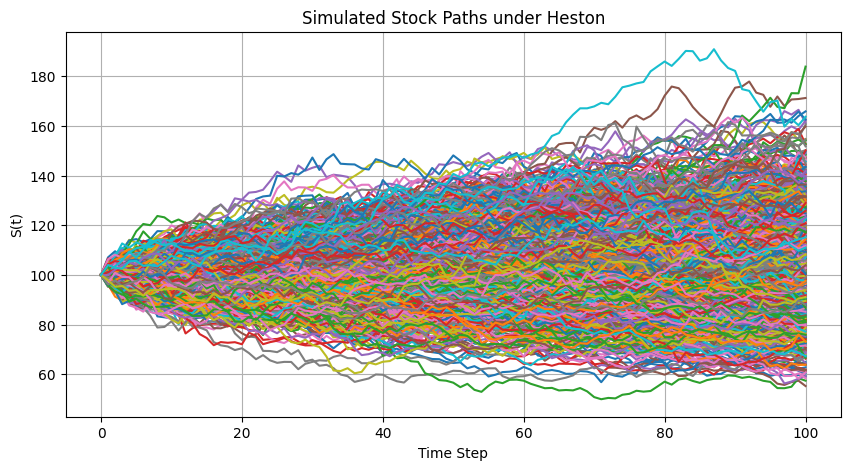

In [24]:
# Run 
S, v = Heston_simulation(S0, K, T, r, v0, theta, kappa, sigma, rho,
                         t_choice, optionType, Nsim, Nt, dt, use_milstein=True)

# Compute arithmetic-average Asian payoff
S_avg = np.mean(S[:, 1:], axis=1)
payoff = np.maximum(S_avg - K, 0)

# Discount back to time 0
option_price = np.exp(-r * T) * np.mean(payoff)
std_error = np.exp(-r * T) * np.std(payoff) / np.sqrt(Nsim)

print(f"Asian Call Option Price: {option_price:.4f}")
print(f"Standard Error: {std_error:.4f}")

# Plot stock paths
plt.figure(figsize=(10, 5))
plt.plot(S.T)
plt.title("Simulated Stock Paths under Heston")
plt.xlabel("Time Step")
plt.ylabel("S(t)")
plt.grid()
plt.show()
